# Projekt: Analiza Churnu Klientów (Telco)

## Cel projektu
Celem projektu jest zrozumienie, jakie czynniki mogą wpływać na odejście klientów (customer churn) w firmie telekomunikacyjnej.

Projekt pozwoli:
* przećwiczyć podstawowe etapy analizy danych (wczytanie, czyszczenie, eksploracja, wizualizacja),
* zidentyfikować najważniejsze zależności pomiędzy cechami klientów a ich skłonnością do rezygnacji,
* przygotować dane do dashboardu w Tableau.

In [ ]:
# Import bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia wizualizacji
sns.set_theme(style="whitegrid")
%matplotlib inline

## Krok 1: Wstępna eksploracja danych 

Wczytujemy dane i sprawdzamy ich podstawową strukturę, typy oraz liczymy Churn Rate.

In [39]:
# 1.1 Wczytanie danych

try:
    df = pd.read_excel('/Users/michalbando/Downloads/Różne/IT/Practima_Projekt_Koncowy/Telco_Cusomer_Churn.xlsx', sheet_name='Telco_Cusomer_Churn')
    print("Plik wczytany pomyślnie.")
except FileNotFoundError:
    print(f"BŁĄD: Plik nie został znaleziony.")
    print("Upewnij się, że plik znajduje się w odpowiednim folderze i nazwa jest poprawna.")


Plik wczytany pomyślnie.


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [40]:
# 1.2 Podstawowe informacje o zbiorze
print(f"Liczba wierszy (klientów): {df.shape[0]}")
print(f"Liczba kolumn: {df.shape[1]}")
print(' ')
df.info()

Liczba wierszy (klientów): 7043
Liczba kolumn: 21
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   obj

In [38]:
# 1.3 Obliczenie Churn Rate
churn_rate = df['Churn'].value_counts(normalize=True)
print("Ogólny wskaźnik Churn Rate:")
print(churn_rate * 100)

Ogólny wskaźnik Churn Rate:
No     73.463013
Yes    26.536987
Name: Churn, dtype: float64


In [9]:
# 1.4 Wstępne statystyki opisowe dla zmiennych numerycznych
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7036.000000,7026.000000
mean,0.162147,32.371149,64.771269,2282.246065
std,0.368612,24.559481,30.090707,2266.211840
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.150000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3791.000000
max,1.000000,72.000000,118.750000,8684.800000


## Krok 2: Czyszczenie danych

Przygotowujemy dane do analizy: usuwamy/uzupełniamy braki i ujednolicamy wartości.

In [42]:
# 2.1 Obsługa brakujących wartości

print("Liczba brakujących wartości:")
print(df.isnull().sum().sort_values(ascending=False))

Liczba brakujących wartości:
TotalCharges        17
MonthlyCharges       7
customerID           0
DeviceProtection     0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
OnlineBackup         0
gender               0
OnlineSecurity       0
InternetService      0
MultipleLines        0
PhoneService         0
tenure               0
Dependents           0
Partner              0
SeniorCitizen        0
Churn                0
dtype: int64


In [ ]:
# 2.2 Uzupełnienie lub usunięcie braków
df_clean = df.dropna().copy()

print(f"Rozmiar danych przed czyszczeniem: {df.shape}")
print(f"Rozmiar danych po czyszczeniu: {df_clean.shape}")

Rozmiar danych przed czyszczeniem: (7043, 21)
Rozmiar danych po czyszczeniu: (7019, 21)


In [43]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
# 2.3 Ujednolicenie wartości kategorycznych
cols_to_replace = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_replace:
    df_clean.loc[:, col] = df_clean[col].replace('No internet service', 'No')    


df_clean.loc[:, 'MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')

print("Zmieniono 'No internet service' i 'No phone service' na 'No'.")

Zmieniono 'No internet service' i 'No phone service' na 'No'.


In [20]:
# 2.4 Zapisanie oczyszczonego zbioru
df_clean.to_csv('telco_churn_clean_for_tableau.csv', index=False)
print("Oczyszczone dane zapisano do pliku 'telco_churn_clean_for_tableau.csv'")

Oczyszczone dane zapisano do pliku 'telco_churn_clean_for_tableau.csv'


## Krok 3: Formułowanie hipotez 

Na podstawie opisu zmiennych i intuicji biznesowej, oto 4 hipotezy badawcze, które sprawdzimy w analizie (inne niż te w instrukcji):

**- H1 (Opłaty):** Klienci, którzy płacą znacznie wyższe rachunki miesięczne (`MonthlyCharges`) niż średnia, odchodzą częściej (bo szukają oszczędności).

**- H2 (Typ Internetu):** Klienci korzystający z internetu światłowodowego (`InternetService` = 'Fiber optic') mają wyższy wskaźnik rezygnacji niż klienci posiadający DSL (być może usługa jest droższa lub bardziej awaryjna).

**- H3 (Wiek):** Seniorzy (`SeniorCitizen` = 1) są bardziej skłonni do rezygnacji niż młodsi klienci (być może są bardziej wrażliwi na cenę lub gorzej radzą sobie z obsługą).

**- H4 (Wsparcie techniczne):** Klienci, którzy nie wykupili usługi wsparcia technicznego (`TechSupport` = 'No'), częściej rezygnują (bo frustrują się problemami, których nie potrafią sami rozwiązać).

## Krok 4: Eksploracyjna analiza danych (EDA)

Weryfikujemy postawione hipotezy za pomocą wizualizacji i prostych statystyk.

### Weryfikacja H1: Opłaty (MonthlyCharges) a Churn

Użyjemy wykresu pudełkowego (boxplot), aby porównać rozkłady opłat miesięcznych dla klientów, którzy odeszli (`Yes`) i zostali (`No`).

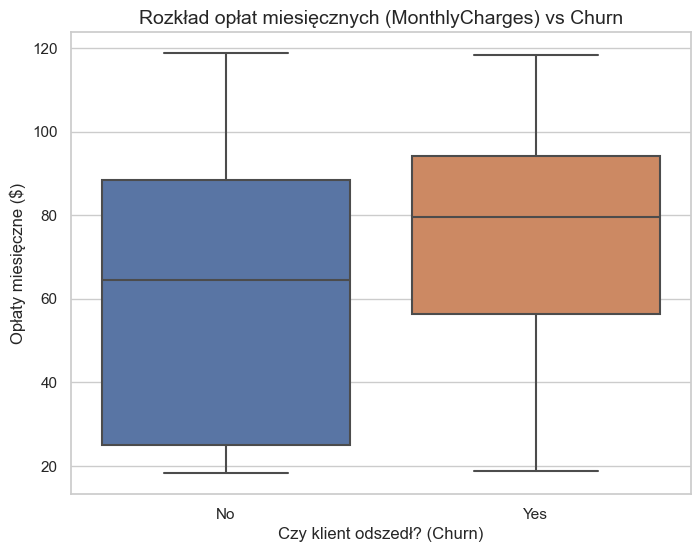

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges')
plt.title('Rozkład opłat miesięcznych (MonthlyCharges) vs Churn', fontsize=14)
plt.xlabel('Czy klient odszedł? (Churn)')
plt.ylabel('Opłaty miesięczne ($)')
plt.show()

Wniosek: 
Wykres pudełkowy wyraźnie pokazuje, że mediana oraz cały przedział międzykwartylowy dla klientów, którzy odeszli (Yes) są położone znacznie wyżej niż dla klientów, którzy zostali (No).
Oznacza to, że klienci rezygnujący z usług płacili średnio wyższe rachunki miesięczne. Wyższa cena może być kluczowym powodem rezygnacji.

### Weryfikacja H2: Typ Internetu (InternetService) a Churn

Użyjemy wykresu słupkowego, aby pokazać jaki procent klientów odchodzi w zależności od posiadanego typu internetu.


In [23]:
# Obliczamy procent churn dla każdej kategorii InternetService
churn_by_internet = df_clean.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack().loc[:, 'Yes'] * 100
churn_by_internet = churn_by_internet.reset_index(name='Churn Rate (%)')

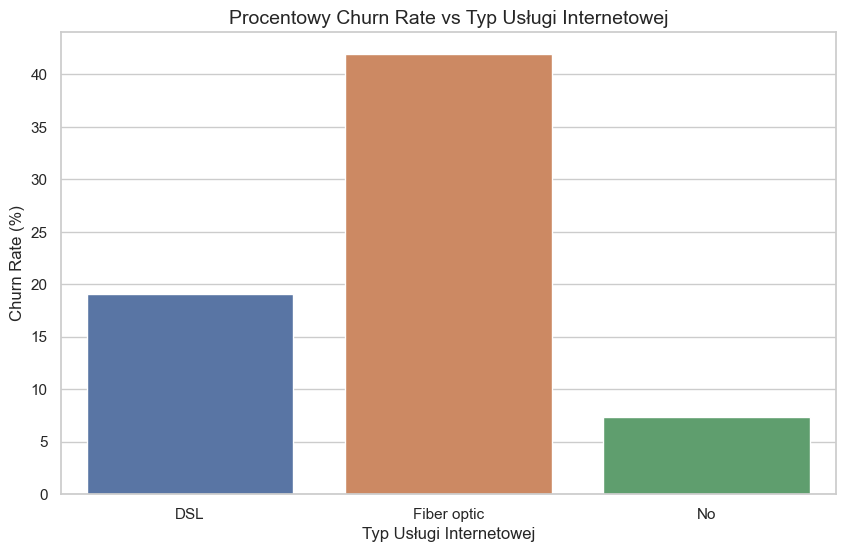

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_by_internet, x='InternetService', y='Churn Rate (%)')
plt.title('Procentowy Churn Rate vs Typ Usługi Internetowej', fontsize=14)
plt.xlabel('Typ Usługi Internetowej')
plt.ylabel('Churn Rate (%)')

plt.show()


Wniosek: Słupek 'Fiber optic' pokazuje wskaźnik rezygnacji na poziomie ponad 40% - jest on dużo wyższy niż dla 'DSL' (poniżej 20%) oraz dla klientów bez dostępu do Internetu ('No' - poniżej 10%).
Posiadanie internetu światłowodowego jest silnie powiązane z wyższym ryzykiem odejścia. Może to wynikać z wyższej ceny usługi, niestabilności tecvhnicznej lub dużej konkurencji ze strony innych firm.

### Weryfikacja H3: Seniorzy (SeniorCitizen) a Churn

Sprawdzamy procentowy wskaźnik rezygnacji dla seniorów i pozostałych klientów.

In [25]:
# Obliczamy procent churn dla SeniorCitizen
churn_by_senior = df_clean.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack().loc[:, 'Yes'] * 100
churn_by_senior = churn_by_senior.reset_index(name='Churn Rate (%)')


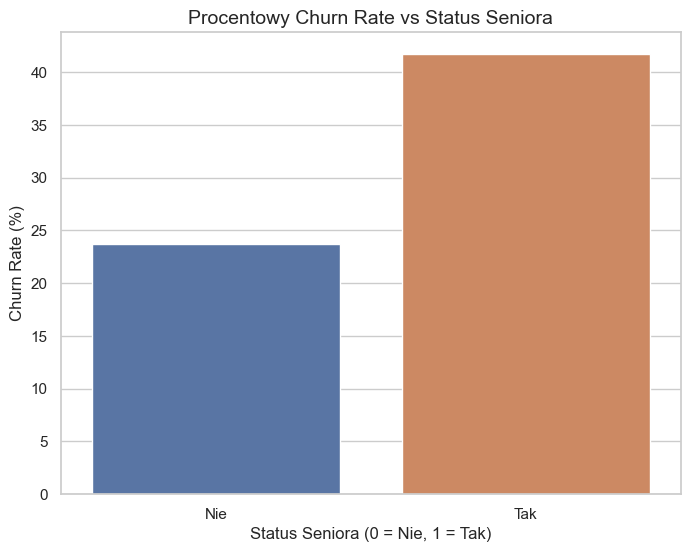

In [34]:
plt.figure(figsize=(8, 6))
sns.barplot(data=churn_by_senior, x='SeniorCitizen', y='Churn Rate (%)')
plt.title('Procentowy Churn Rate vs Status Seniora', fontsize=14)
plt.xlabel('Status Seniora (0 = Nie, 1 = Tak)')
plt.ylabel('Churn Rate (%)')
plt.xticks([0, 1], ['Nie', 'Tak'])
plt.show()

Wniosek: Słupek 'Tak' jest wyraźnie wyższy (ponad 40%) niż dla klientów, którzy nie są seniorami ('Nie') - poniżej 25%. 
Seniorzy rezynują prawie dwukrotnie częściej niż pozostali klienci - może mieć to podstawy w np. problemach z obsługą nowych technologii lub ze zbyt wysoką ceną.

### Weryfikacja H4: Wsparcie techniczne (TechSupport) a Churn

Porównujemy Churn Rate dla klientów z i bez wsparcia technicznego.

In [28]:
# Obliczamy procent churn dla TechSupport
churn_by_tech = df_clean.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack().loc[:, 'Yes'] * 100
churn_by_tech = churn_by_tech.reset_index(name='Churn Rate (%)')


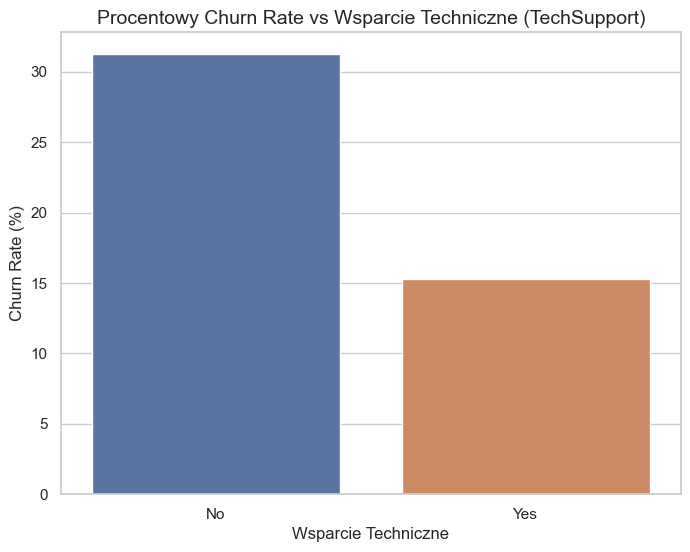

In [35]:
plt.figure(figsize=(8, 6))
sns.barplot(data=churn_by_tech, x='TechSupport', y='Churn Rate (%)')
plt.title('Procentowy Churn Rate vs Wsparcie Techniczne (TechSupport)', fontsize=14)
plt.xlabel('Wsparcie Techniczne')
plt.ylabel('Churn Rate (%)')
plt.show()

Wniosek: Słupek dla klientów bez wsparcia technicznego jest wyraźnie wyższy niż dla tych, którzy korzystali ze wsparcia technicznego. 
Klienci bez wsparcia technicznego rezygnowali ponad dwukrotnie częściej niż ci, którzy mieli tę usługę. Może mieć to podłoże frustracji (np. problemy techniczne). Klienci płacący za wsparcie są bardziej lojalni.